# OncoBridge-MMCAT — Data Processing & EDA v3
## CCLE + GDSC1/2 · Morgan Fingerprints · Stratified Splits

### What's new in v3:
| Fix | Description |
|-----|-------------|
| SMILES / Morgan FP | PubChem fetch → 2048-bit ECFP4 per drug |
| USE_GDSC1 flag | Toggle GDSC1+2 combined vs GDSC2-only (fair benchmark) |
| LN IC50 | Proper log2→ln conversion (×ln(2)) |
| Stratified split | StratifiedShuffleSplit by cancer type |
| Drug cold-start split | 15% drugs held out for drug cold-start eval |
| Missing data mask | Binary mask saved alongside omics |
| Methylation fix | Continuous [0,1] — no-scale justified correctly |
| Per-drug IC50 threshold | Iorio-style per-drug binarisation thresholds saved |


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — INSTALLS  (run once; Kaggle caches pip packages)
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs],
                   check=True)

# Changed 'rdkit-pypi' to 'rdkit'
pip('pubchempy', 'rdkit')
print('✓ pubchempy  ✓ rdkit  (all other packages already on Kaggle)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 54.1 MB/s eta 0:00:00
✓ pubchempy  ✓ rdkit  (all other packages already on Kaggle)


In [2]:
from rdkit import Chem
print("RDKit working")

RDKit working


In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — IMPORTS & HELPERS
# ═══════════════════════════════════════════════════════════════════════
import os, re, gc, json, time, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from scipy import stats

# RDKit
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, DataStructs
RDLogger.DisableLog('rdApp.*')

# PubChemPy
import pubchempy as pcp

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

def section(t):
    print('\n' + '═'*70)
    print(f'  {t}')
    print('═'*70)

def mem_usage(df, name):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'  [{name}] RAM: {mb:.1f} MB | shape: {df.shape}')

print('Imports OK.')


Imports OK.


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — CONFIG  ← edit paths and flags here
# ═══════════════════════════════════════════════════════════════════════

CFG = dict(
    # ── Dataset toggle ──────────────────────────────────────────────────
    USE_GDSC1 = True,   # True  = GDSC1+2 combined (more data, biased benchmark)
                        # False = GDSC2 only       (fair comparison vs literature)

    # ── IC50 scale ──────────────────────────────────────────────────────
    IC50_SCALE = 'ln',  # 'ln' = multiply log2 by ln(2)  [REQUIRED for fair RMSE]
                        # 'log2' = keep raw sanger log2

    # ── Drug / cell line filters ────────────────────────────────────────
    MIN_SAMPLES_PER_DRUG     = 100,   # drop drugs with < N cell-line measurements
    MIN_SAMPLES_PER_CELLLINE = 10,    # drop cell lines with < N drug measurements

    # ── Drug cold-start split ────────────────────────────────────────────
    DRUG_COLD_FRAC = 0.15,  # fraction of drugs held out for cold-start eval

    # ── Morgan fingerprint params ────────────────────────────────────────
    FP_RADIUS = 2,      # ECFP4 (radius 2)
    FP_BITS   = 2048,

    # ── Gene dims — must match TCGA Phase 1 training ─────────────────────
    N_MRNA  = 8011,
    N_CNV   = 3500,
    N_MUT   = 2500,
    N_METH  = 6000,

    # ── Cell-line split ──────────────────────────────────────────────────
    VAL_FRAC   = 0.10,
    TEST_FRAC  = 0.20,
    SEED       = 42,

    # ── Paths ─────────────────────────────────────────────────────────────
    BASE        = '/kaggle/input/datasets/proutkarshtiwari/drug-cell-line-data-phase-2',  # ← update
    SANGER_CSV  = 'sanger-dose-response.csv',
    MODEL_CSV   = 'Model.csv',
    MRNA_CSV    = 'OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv',
    CNV_CSV     = 'OmicsCNGeneWGS.csv',
    MUT_CSV     = 'OmicsSomaticMutationsMatrixDamaging.csv',
    METH_CSV    = 'CCLE_RRBS_TSS_1kb_20180614.txt',
    GENE_JSON   = '/kaggle/input/datasets/proutkarshtiwari/drug-cell-line-data-phase-2/selected_genes.json',
    SMILES_CACHE = '/kaggle/working/drug_smiles_cache.csv',
    FP_CACHE     = '/kaggle/working/drug_fp_cache.pkl',
    OUT_DIR      = '/kaggle/working/',
)

DATASETS = ['GDSC1', 'GDSC2'] if CFG['USE_GDSC1'] else ['GDSC2']
print(f'USE_GDSC1 = {CFG["USE_GDSC1"]}  →  Datasets: {DATASETS}')
print(f'IC50_SCALE = {CFG["IC50_SCALE"]}')
print(f'Morgan FP: radius={CFG["FP_RADIUS"]}, bits={CFG["FP_BITS"]}')
print(f'Drug cold-start hold-out: {CFG["DRUG_COLD_FRAC"]*100:.0f}% of drugs')


USE_GDSC1 = True  →  Datasets: ['GDSC1', 'GDSC2']
IC50_SCALE = ln
Morgan FP: radius=2, bits=2048
Drug cold-start hold-out: 15% of drugs


In [5]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — LOAD TCGA GENE LISTS (Phase 1 anchor)
# ═══════════════════════════════════════════════════════════════════════
section('4. TCGA GENE LISTS')

with open(CFG['GENE_JSON']) as f:
    gene_names = json.load(f)

GENES = {
    'mrna': gene_names['mrna'],
    'cnv':  gene_names['cnv'],
    'mut':  gene_names['mut'],
    'meth': gene_names['meth'],
}

print('Gene counts from Phase 1 training:')
for k, v in GENES.items():
    print(f'  {k:>4}: {len(v):>6,} genes')
print(f'  Total features: {sum(len(v) for v in GENES.values()):,}')



══════════════════════════════════════════════════════════════════════
  4. TCGA GENE LISTS
══════════════════════════════════════════════════════════════════════
Gene counts from Phase 1 training:
  mrna:  8,011 genes
   cnv:  3,500 genes
   mut:  2,500 genes
  meth:  6,000 genes
  Total features: 20,011



══════════════════════════════════════════════════════════════════════
  5. SANGER IC50 LABELS
══════════════════════════════════════════════════════════════════════
Raw shape: (387626, 20)
Datasets in file: ['GDSC1' 'GDSC2']
After dataset filter (['GDSC1', 'GDSC2']): 387,626 rows
Converted log2(IC50) → ln(IC50) [×0.6931]
IC50 stats: mean=0.163  std=2.549  range=[-9.26, 8.29]
After deduplication (GDSC2 preferred): 92,667 rows
After drug filter (≥100 samples): 87,728 rows | 215 drugs
After cell line filter (≥10 drugs): 87,693 rows

Final: 87,693 IC50 pairs | 215 drugs | 981 cell lines
Elapsed: 2.3s


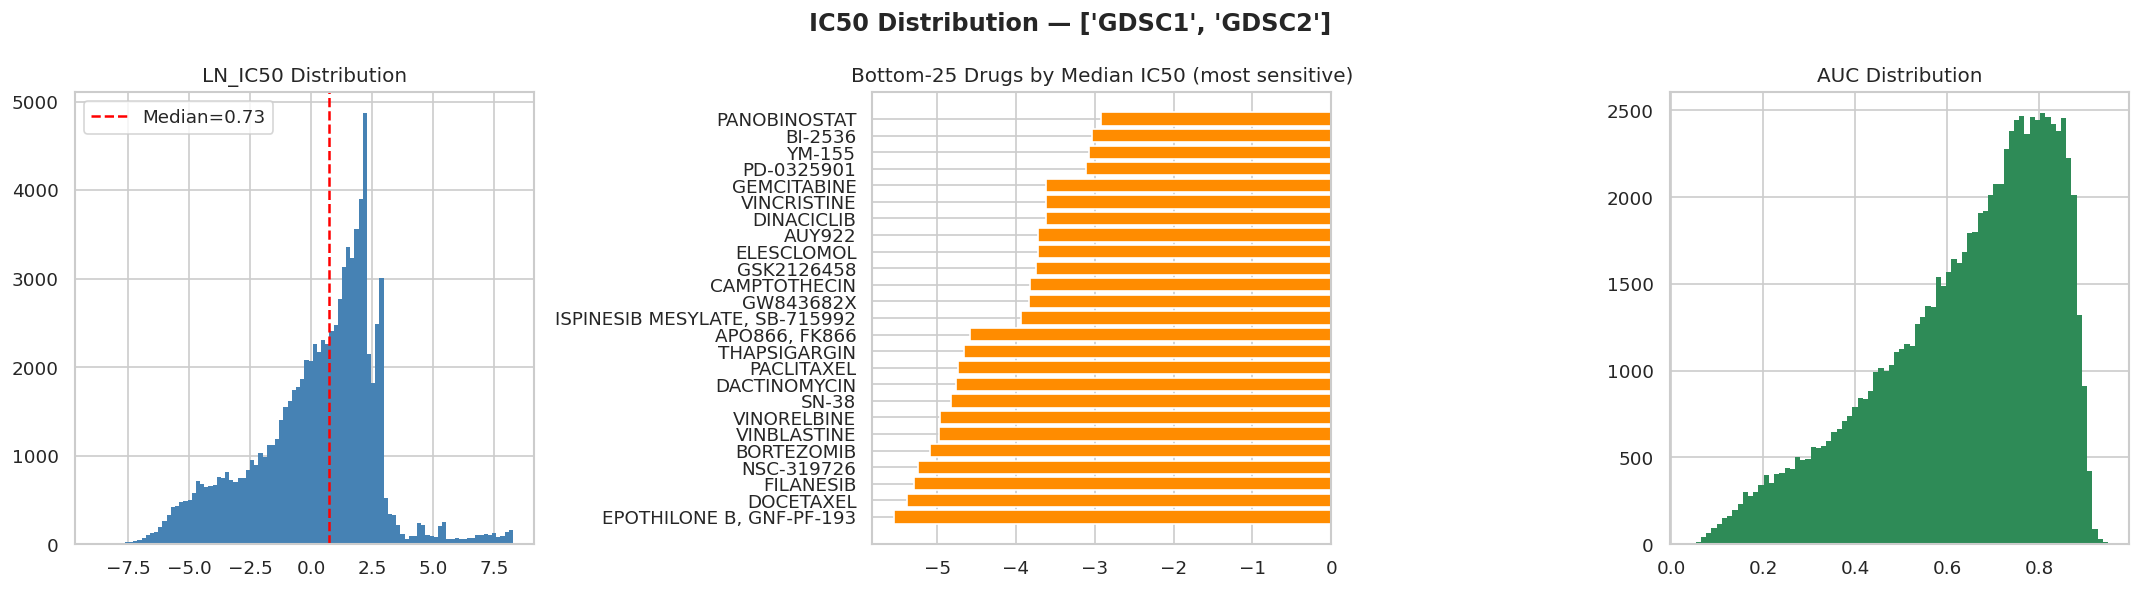

In [6]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — SANGER IC50 LABELS
# ═══════════════════════════════════════════════════════════════════════
section('5. SANGER IC50 LABELS')

t0 = time.time()
raw = pd.read_csv(f"{CFG['BASE']}/{CFG['SANGER_CSV']}", low_memory=False)
print(f'Raw shape: {raw.shape}')
print(f'Datasets in file: {raw["DATASET"].unique()}')

# ── Filter to selected datasets ─────────────────────────────────────────
ic50 = raw[raw['DATASET'].isin(DATASETS)].copy()
print(f'After dataset filter ({DATASETS}): {len(ic50):,} rows')

# ── Drop missing IC50 ───────────────────────────────────────────────────
ic50 = ic50.dropna(subset=['log2.ic50'])

# ── Scale conversion: log2 → ln ─────────────────────────────────────────
LN2 = np.log(2)   # ≈ 0.6931
if CFG['IC50_SCALE'] == 'ln':
    ic50['ic50_value'] = ic50['log2.ic50'] * LN2
    print(f'Converted log2(IC50) → ln(IC50) [×{LN2:.4f}]')
else:
    ic50['ic50_value'] = ic50['log2.ic50']

print(f'IC50 stats: mean={ic50["ic50_value"].mean():.3f}  '
      f'std={ic50["ic50_value"].std():.3f}  '
      f'range=[{ic50["ic50_value"].min():.2f}, {ic50["ic50_value"].max():.2f}]')

# ── Deduplicate: prefer GDSC2 when the same pair exists in both ──────────
ic50 = ic50.sort_values('DATASET', ascending=False)  # GDSC2 > GDSC1 alphabetically
ic50 = ic50.drop_duplicates(subset=['COSMIC_ID', 'DRUG_NAME'], keep='first')
print(f'After deduplication (GDSC2 preferred): {len(ic50):,} rows')

# ── Drug coverage filter ─────────────────────────────────────────────────
drug_counts = ic50['DRUG_NAME'].value_counts()
valid_drugs = drug_counts[drug_counts >= CFG['MIN_SAMPLES_PER_DRUG']].index
ic50 = ic50[ic50['DRUG_NAME'].isin(valid_drugs)]
print(f'After drug filter (≥{CFG["MIN_SAMPLES_PER_DRUG"]} samples): '
      f'{len(ic50):,} rows | {ic50["DRUG_NAME"].nunique()} drugs')

# ── Cell line filter ─────────────────────────────────────────────────────
cl_counts = ic50.groupby('COSMIC_ID').size()
valid_cls  = cl_counts[cl_counts >= CFG['MIN_SAMPLES_PER_CELLLINE']].index
ic50 = ic50[ic50['COSMIC_ID'].isin(valid_cls)]
print(f'After cell line filter (≥{CFG["MIN_SAMPLES_PER_CELLLINE"]} drugs): '
      f'{len(ic50):,} rows')

# ── Finalise columns ─────────────────────────────────────────────────────
ic50 = ic50[['COSMIC_ID','DRUG_NAME','DATASET','ic50_value',
             'AUC_PUBLISHED','Z_SCORE_PUBLISHED']].copy()
ic50 = ic50.rename(columns={'AUC_PUBLISHED':'AUC','Z_SCORE_PUBLISHED':'Z_SCORE'})
ic50['COSMIC_ID'] = ic50['COSMIC_ID'].astype(int)

DRUG_NAMES = sorted(ic50['DRUG_NAME'].unique())
print(f'\nFinal: {len(ic50):,} IC50 pairs | {ic50["DRUG_NAME"].nunique()} drugs | '
      f'{ic50["COSMIC_ID"].nunique()} cell lines')
print(f'Elapsed: {time.time()-t0:.1f}s')
del raw; gc.collect()

# ── EDA ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'IC50 Distribution — {DATASETS}', fontweight='bold')
axes[0].hist(ic50['ic50_value'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('LN_IC50 Distribution')
axes[0].axvline(ic50['ic50_value'].median(), color='red', ls='--',
                label=f'Median={ic50["ic50_value"].median():.2f}')
axes[0].legend()

drug_med = ic50.groupby('DRUG_NAME')['ic50_value'].median().sort_values().head(25)
axes[1].barh(drug_med.index, drug_med.values, color='darkorange')
axes[1].set_title('Bottom-25 Drugs by Median IC50 (most sensitive)')

axes[2].hist(ic50['AUC'].dropna(), bins=80, color='seagreen', edgecolor='none')
axes[2].set_title('AUC Distribution')
plt.tight_layout(); plt.show()


In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — FETCH SMILES FROM PUBCHEM (cached)
# ═══════════════════════════════════════════════════════════════════════
section('6. SMILES FROM PUBCHEM')

def clean_name(name):
    """Return primary name from GDSC alias strings like 'Drug A; Drug B'."""
    primary = name.split(';')[0].strip()
    primary = re.sub(r'\s*\(.*?\)', '', primary).strip()
    return primary

def fetch_smiles(name, timeout=15):
    try:
        res = pcp.get_compounds(name, 'name', timeout=timeout)
        if res:
            return res[0].isomeric_smiles or res[0].canonical_smiles
    except Exception:
        pass
    return None

def load_or_fetch_smiles(drug_names, cache_path, sleep=0.4):
    cache_path = Path(cache_path)
    cache = {}
    if cache_path.exists():
        df_c = pd.read_csv(cache_path)
        cache = {r['drug_name']: (None if pd.isna(r['smiles']) else r['smiles'])
                 for _, r in df_c.iterrows()}
        print(f'  Loaded {len(cache)} cached SMILES entries')

    missing = [d for d in drug_names if d not in cache]
    print(f'  Need to fetch: {len(missing)} drugs')

    for i, name in enumerate(missing):
        smiles = fetch_smiles(clean_name(name))
        if smiles is None and ';' in name:
            for alias in name.split(';'):
                smiles = fetch_smiles(alias.strip())
                if smiles: break
        cache[name] = smiles
        if (i+1) % 10 == 0 or i == len(missing)-1:
            ok = 'OK' if smiles else 'MISSING'
            print(f'  {i+1}/{len(missing)}  {name[:50]:<50}  {ok}')
            time.sleep(sleep)

    pd.DataFrame(
        [(k, v) for k, v in cache.items()],
        columns=['drug_name', 'smiles']
    ).to_csv(cache_path, index=False)
    return cache

print(f'Fetching SMILES for {len(DRUG_NAMES)} drugs from PubChem...')
smiles_map = load_or_fetch_smiles(DRUG_NAMES, CFG['SMILES_CACHE'])

n_ok   = sum(1 for v in smiles_map.values() if v is not None)
n_miss = len(smiles_map) - n_ok
print(f'\nSMILES found:   {n_ok}/{len(smiles_map)} ({n_ok/len(smiles_map)*100:.1f}%)')
print(f'SMILES missing: {n_miss}  (these drugs will be EXCLUDED from training)')



══════════════════════════════════════════════════════════════════════
  6. SMILES FROM PUBCHEM
══════════════════════════════════════════════════════════════════════
Fetching SMILES for 215 drugs from PubChem...
  Need to fetch: 215 drugs
  10/215  ALISERTIB                                           OK
  20/215  AST-1306                                            OK
  30/215  AZD8055                                             OK
  40/215  BORTEZOMIB                                          OK
  50/215  CAY10603                                            OK
  60/215  CX-5461                                             OK
  70/215  ELEPHANTIN                                          OK
  80/215  FLUDARABINE                                         OK
  90/215  GSK2126458                                          OK
  100/215  JNK-9L, KIN001-204                                  MISSING
  110/215  KRAS (G12C) INHIBITOR-12, GTPL8020                  MISSING
  120/215  MITOXANTRONE         


══════════════════════════════════════════════════════════════════════
  7. MORGAN FINGERPRINTS
══════════════════════════════════════════════════════════════════════
Computed and cached FPs for 168 drugs

Drugs with valid FP: 168/215
IC50 rows after FP filter: 87,693 → 68,677
FP_MATRIX shape: (168, 2048)  dtype: float32


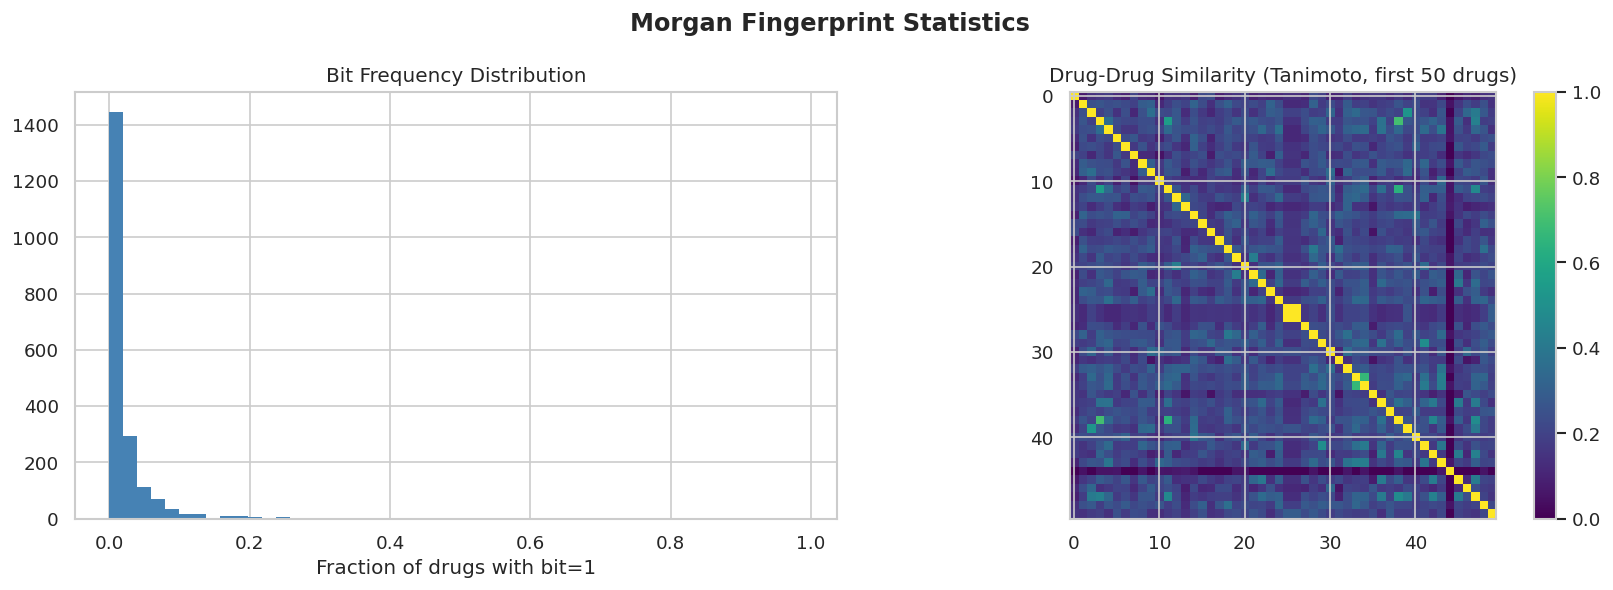

In [8]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — MORGAN FINGERPRINTS (ECFP4)
# ═══════════════════════════════════════════════════════════════════════
section('7. MORGAN FINGERPRINTS')

def smiles_to_fp(smiles, radius=2, n_bits=2048):
    if not isinstance(smiles, str): return None
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        fp  = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        arr = np.zeros(n_bits, dtype=np.float32)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    except Exception:
        return None

fp_cache_path = Path(CFG['FP_CACHE'])
if fp_cache_path.exists():
    with open(fp_cache_path, 'rb') as f:
        drug_fp = pickle.load(f)
    print(f'Loaded FP cache ({len(drug_fp)} drugs)')
else:
    drug_fp = {}
    for name in DRUG_NAMES:
        fp = smiles_to_fp(smiles_map.get(name), CFG['FP_RADIUS'], CFG['FP_BITS'])
        if fp is not None:
            drug_fp[name] = fp
        else:
            print(f'  WARNING: No valid FP for "{name[:50]}" — will exclude')
    with open(fp_cache_path, 'wb') as f:
        pickle.dump(drug_fp, f)
    print(f'Computed and cached FPs for {len(drug_fp)} drugs')

VALID_DRUG_NAMES = sorted(drug_fp.keys())
print(f'\nDrugs with valid FP: {len(VALID_DRUG_NAMES)}/{len(DRUG_NAMES)}')

# Filter IC50 to drugs with FP
before = len(ic50)
ic50 = ic50[ic50['DRUG_NAME'].isin(VALID_DRUG_NAMES)].copy()
print(f'IC50 rows after FP filter: {before:,} → {len(ic50):,}')

# Drug → index mapping
drug2idx = {d: i for i, d in enumerate(VALID_DRUG_NAMES)}
ic50['drug_idx'] = ic50['DRUG_NAME'].map(drug2idx)

# Stack FP matrix  (n_drugs, FP_BITS)
FP_MATRIX = np.stack([drug_fp[d] for d in VALID_DRUG_NAMES], axis=0)
print(f'FP_MATRIX shape: {FP_MATRIX.shape}  dtype: {FP_MATRIX.dtype}')

# ── FP EDA ───────────────────────────────────────────────────────────────
bit_freq = FP_MATRIX.mean(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Morgan Fingerprint Statistics', fontweight='bold')
axes[0].hist(bit_freq, bins=50, color='steelblue', edgecolor='none')
axes[0].set_title('Bit Frequency Distribution')
axes[0].set_xlabel('Fraction of drugs with bit=1')
tanimoto_samp = FP_MATRIX[:50]
sim = tanimoto_samp @ tanimoto_samp.T
norms = np.sqrt((tanimoto_samp**2).sum(1, keepdims=True))
sim = sim / (norms * norms.T + 1e-8)
axes[1].imshow(sim, cmap='viridis', vmin=0, vmax=1)
axes[1].set_title('Drug-Drug Similarity (Tanimoto, first 50 drugs)')
plt.colorbar(axes[1].images[0], ax=axes[1])
plt.tight_layout(); plt.show()


In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — DRUG COLD-START SPLIT
#  Hold out 15% of drugs for cold-start evaluation.
#  These drugs are NEVER seen during training — tests generalisation.
# ═══════════════════════════════════════════════════════════════════════
section('8. DRUG COLD-START SPLIT')

np.random.seed(CFG['SEED'])
drug_arr = np.array(VALID_DRUG_NAMES)
n_cold = max(1, int(len(drug_arr) * CFG['DRUG_COLD_FRAC']))

cold_start_drugs = np.random.choice(drug_arr, size=n_cold, replace=False)
warmstart_drugs  = [d for d in VALID_DRUG_NAMES if d not in set(cold_start_drugs)]

ic50_warm = ic50[ic50['DRUG_NAME'].isin(warmstart_drugs)].copy()
ic50_cold = ic50[ic50['DRUG_NAME'].isin(cold_start_drugs)].copy()

print(f'Warm-start drugs (used for main training+eval): {len(warmstart_drugs)}')
print(f'Cold-start drugs (held out, test generalization): {len(cold_start_drugs)}')
print(f'  Cold-start drug names: {list(cold_start_drugs[:10])} ...')
print(f'\nIC50 pairs in warm set: {len(ic50_warm):,}')
print(f'IC50 pairs in cold set: {len(ic50_cold):,}')

# Save cold-start drug list
with open(f"{CFG['OUT_DIR']}/cold_start_drugs.json", 'w') as f:
    json.dump({'cold_start': list(cold_start_drugs),
               'warm_start': warmstart_drugs}, f, indent=2)
print('Saved: cold_start_drugs.json')



══════════════════════════════════════════════════════════════════════
  8. DRUG COLD-START SPLIT
══════════════════════════════════════════════════════════════════════
Warm-start drugs (used for main training+eval): 143
Cold-start drugs (held out, test generalization): 25
  Cold-start drug names: [np.str_('TAK-715'), np.str_('BORTEZOMIB'), np.str_('PONATINIB'), np.str_('BMS-754807'), np.str_('TENOVIN-6'), np.str_('WZ3105'), np.str_('YM-201636'), np.str_('DACOMITINIB'), np.str_('OBATOCLAX'), np.str_('ENTINOSTAT')] ...

IC50 pairs in warm set: 58,290
IC50 pairs in cold set: 10,387
Saved: cold_start_drugs.json


In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — MODEL.CSV — CELL LINE METADATA & ID MAPPING
# ═══════════════════════════════════════════════════════════════════════
section('9. MODEL.CSV — ID MAPPING')

model_df = pd.read_csv(f"{CFG['BASE']}/{CFG['MODEL_CSV']}")
model_df = model_df[['ModelID','CellLineName','COSMICID',
                      'OncotreePrimaryDisease','OncotreeLineage',
                      'OncotreeSubtype','CCLEName']].copy()
model_df = model_df.dropna(subset=['COSMICID'])
model_df['COSMICID'] = model_df['COSMICID'].astype(int)
print(f'Model.csv: {len(model_df)} rows | {model_df["COSMICID"].nunique()} unique COSMICs')

# Join IC50 + metadata
ic50_warm = ic50_warm.merge(model_df, left_on='COSMIC_ID', right_on='COSMICID', how='inner')
ic50_cold  = ic50_cold.merge(model_df, left_on='COSMIC_ID', right_on='COSMICID', how='inner')

print(f'After join — warm: {len(ic50_warm):,} | cold: {len(ic50_cold):,}')
print(f'Unique cell lines in warm set: {ic50_warm["ModelID"].nunique()}')
print(f'Unique cancer types: {ic50_warm["OncotreePrimaryDisease"].nunique()}')

valid_model_ids = set(ic50_warm['ModelID'].unique()) | set(ic50_cold['ModelID'].unique())



══════════════════════════════════════════════════════════════════════
  9. MODEL.CSV — ID MAPPING
══════════════════════════════════════════════════════════════════════
Model.csv: 977 rows | 977 unique COSMICs
After join — warm: 56,783 | cold: 10,128
Unique cell lines in warm set: 956
Unique cancer types: 73


In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — CCLE mRNA EXPRESSION
# ═══════════════════════════════════════════════════════════════════════
section('10. CCLE mRNA')

mrna_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['MRNA_CSV']}", index_col=0, low_memory=False)
print(f'Raw shape: {mrna_raw.shape}')

if 'IsDefaultEntryForModel' in mrna_raw.columns:
    mrna_raw = mrna_raw[mrna_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    mrna_raw = mrna_raw.set_index('ModelID')
    mrna_raw = mrna_raw.drop(columns=['SequencingID','ModelConditionID',
                                       'IsDefaultEntryForMC','IsDefaultEntryForModel'],
                               errors='ignore')

mrna_raw.columns = [str(c).split(' (')[0].strip() for c in mrna_raw.columns]
mrna_raw = mrna_raw.loc[:, ~mrna_raw.columns.duplicated(keep='first')]
mrna_raw = mrna_raw[mrna_raw.index.isin(valid_model_ids)]

overlap_m = set(mrna_raw.columns) & set(GENES['mrna'])
print(f'mRNA overlap with TCGA genes: {len(overlap_m)}/{len(GENES["mrna"])}')

mrna_df = mrna_raw.reindex(columns=GENES['mrna'], fill_value=0.0).fillna(0.0).astype(np.float32)
mrna_mask = (~mrna_raw.reindex(columns=GENES['mrna']).isna()).astype(np.float32)
mrna_mask.columns = [f'mask_{c}' for c in mrna_mask.columns]

print(f'Final mRNA: {mrna_df.shape}')
valid_model_ids_mrna = set(mrna_df.index)
del mrna_raw; gc.collect()

mem_usage(mrna_df, 'mRNA')



══════════════════════════════════════════════════════════════════════
  10. CCLE mRNA
══════════════════════════════════════════════════════════════════════
Raw shape: (1775, 19220)
mRNA overlap with TCGA genes: 7374/8011
Final mRNA: (709, 8011)
  [mRNA] RAM: 22.8 MB | shape: (709, 8011)


In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — CCLE CNV
# ═══════════════════════════════════════════════════════════════════════
section('11. CCLE CNV')

cnv_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['CNV_CSV']}", index_col=0, low_memory=False)
if 'IsDefaultEntryForModel' in cnv_raw.columns:
    cnv_raw = cnv_raw[cnv_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    cnv_raw = cnv_raw.set_index('ModelID')
    cnv_raw = cnv_raw.drop(columns=['SequencingID','ModelConditionID',
                                     'IsDefaultEntryForMC','IsDefaultEntryForModel'],
                            errors='ignore')
cnv_raw.columns = [str(c).split(' (')[0].strip() for c in cnv_raw.columns]
cnv_raw = cnv_raw.loc[:, ~cnv_raw.columns.duplicated(keep='first')]
cnv_raw = cnv_raw[cnv_raw.index.isin(valid_model_ids)]
cnv_raw = cnv_raw.fillna(1.0).clip(lower=0.01)
cnv_raw = np.log2(cnv_raw / 2.0).astype(np.float32)  # log2(CN/2): 0=diploid

overlap_c = set(cnv_raw.columns) & set(GENES['cnv'])
print(f'CNV overlap with TCGA genes: {len(overlap_c)}/{len(GENES["cnv"])}')
cnv_df = cnv_raw.reindex(columns=GENES['cnv'], fill_value=0.0).astype(np.float32)
print(f'Final CNV: {cnv_df.shape}')
valid_model_ids_cnv = set(cnv_df.index)
del cnv_raw; gc.collect()
mem_usage(cnv_df, 'CNV')



══════════════════════════════════════════════════════════════════════
  11. CCLE CNV
══════════════════════════════════════════════════════════════════════
CNV overlap with TCGA genes: 3232/3500
Final CNV: (508, 3500)
  [CNV] RAM: 7.1 MB | shape: (508, 3500)


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — CCLE MUTATION
# ═══════════════════════════════════════════════════════════════════════
section('12. CCLE MUTATION')

mut_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['MUT_CSV']}", index_col=0, low_memory=False)
if 'IsDefaultEntryForModel' in mut_raw.columns:
    mut_raw = mut_raw[mut_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    mut_raw = mut_raw.set_index('ModelID')
    mut_raw = mut_raw.drop(columns=['SequencingID','ModelConditionID',
                                     'IsDefaultEntryForMC','IsDefaultEntryForModel'],
                            errors='ignore')
mut_raw.columns = [str(c).split(' (')[0].strip() for c in mut_raw.columns]
mut_raw = mut_raw.loc[:, ~mut_raw.columns.duplicated(keep='first')]
mut_raw = mut_raw[mut_raw.index.isin(valid_model_ids)]
mut_raw = mut_raw.fillna(0).clip(0, 1).round(0).astype(np.int8)

overlap_u = set(mut_raw.columns) & set(GENES['mut'])
print(f'Mutation overlap with TCGA genes: {len(overlap_u)}/{len(GENES["mut"])}')
sparsity = (mut_raw == 0).mean().mean()
print(f'Sparsity (wildtype fraction): {sparsity*100:.1f}%')
mut_df = mut_raw.reindex(columns=GENES['mut'], fill_value=0).astype(np.float32)
print(f'Final Mutation: {mut_df.shape}')
valid_model_ids_mut = set(mut_df.index)
del mut_raw; gc.collect()
mem_usage(mut_df, 'Mutation')



══════════════════════════════════════════════════════════════════════
  12. CCLE MUTATION
══════════════════════════════════════════════════════════════════════
Mutation overlap with TCGA genes: 2380/2500
Sparsity (wildtype fraction): 99.6%
Final Mutation: (945, 2500)
  [Mutation] RAM: 9.5 MB | shape: (945, 2500)


In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — CCLE METHYLATION (RRBS)
#  NOTE: beta values are CONTINUOUS [0,1] — NOT binary.
#  No scaling is correct because [0,1] is already bounded and comparable
#  across genes/samples. StandardScaler would distort this meaningful scale.
# ═══════════════════════════════════════════════════════════════════════
section('13. CCLE METHYLATION')

meth_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['METH_CSV']}", sep='\t', low_memory=False)
# Determine gene/probe column and transpose
gene_col = meth_raw.iloc[:, 0].values
meth_raw = meth_raw.iloc[:, 1:].apply(pd.to_numeric, errors='coerce').astype(np.float32)
meth_raw.index = gene_col

# Average over multiple TSS regions per gene
meth_raw = meth_raw.groupby(meth_raw.index).mean()
meth_raw = meth_raw.T  # rows=cell lines

# Map CCLE names → ModelIDs
model_map = pd.read_csv(f"{CFG['BASE']}/{CFG['MODEL_CSV']}", usecols=['ModelID','CCLEName'])
model_map = model_map.dropna(subset=['CCLEName'])
ccle_to_model = dict(zip(model_map['CCLEName'], model_map['ModelID']))
meth_raw.index = meth_raw.index.map(lambda x: ccle_to_model.get(x, None))
meth_raw = meth_raw[meth_raw.index.notna()].astype(str)
# Restore index back to string ModelIDs properly
meth_raw.index = meth_raw.index.astype(str)
meth_raw = meth_raw[meth_raw.index.isin(valid_model_ids)]
meth_raw = meth_raw.apply(pd.to_numeric, errors='coerce').astype(np.float32)

# Impute missing with gene-wise mean, then 0.5 for fully missing genes
gene_means = meth_raw.mean(axis=0)
meth_raw = meth_raw.fillna(gene_means).fillna(0.5).clip(0.0, 1.0)

overlap_e = set(meth_raw.columns) & set(GENES['meth'])
print(f'Methylation overlap with TCGA genes: {len(overlap_e)}/{len(GENES["meth"])}')

# Missing in CCLE → fill with 0.5 (neutral, uninformative)
meth_df = meth_raw.reindex(columns=GENES['meth'], fill_value=0.5).astype(np.float32)
print(f'Final Methylation: {meth_df.shape}')
print('No-scale rationale: beta [0,1] is bounded continuous — '
      'StandardScaler would destroy the 0=unmethylated, 1=methylated semantics.')
valid_model_ids_meth = set(meth_df.index)
del meth_raw; gc.collect()
mem_usage(meth_df, 'Methylation')



══════════════════════════════════════════════════════════════════════
  13. CCLE METHYLATION
══════════════════════════════════════════════════════════════════════
Methylation overlap with TCGA genes: 0/6000
Final Methylation: (562, 6000)
No-scale rationale: beta [0,1] is bounded continuous — StandardScaler would destroy the 0=unmethylated, 1=methylated semantics.
  [Methylation] RAM: 13.5 MB | shape: (562, 6000)


In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 14 — MASTER ALIGNMENT
# ═══════════════════════════════════════════════════════════════════════
section('14. MASTER ALIGNMENT')

print('Cell lines per modality:')
print(f'  mRNA: {len(valid_model_ids_mrna)}'
      f'  CNV: {len(valid_model_ids_cnv)}'
      f'  Mut: {len(valid_model_ids_mut)}'
      f'  Meth: {len(valid_model_ids_meth)}')

# All 4 modalities
common_all4  = valid_model_ids_mrna & valid_model_ids_cnv & valid_model_ids_mut & valid_model_ids_meth
common_no_meth = (valid_model_ids_mrna & valid_model_ids_cnv & valid_model_ids_mut
                  & valid_model_ids - valid_model_ids_meth)

# Add imputed methylation rows (0.5) for cell lines missing methylation
if len(common_no_meth) > 0:
    imp = pd.DataFrame(0.5, index=list(common_no_meth), columns=GENES['meth'], dtype=np.float32)
    meth_df = pd.concat([meth_df, imp])
    print(f'Imputed methylation for {len(common_no_meth)} cell lines (all 0.5)')

common_final = sorted(common_all4 | common_no_meth)
print(f'Final usable cell lines: {len(common_final)}')

# Align all dataframes
mrna_df = mrna_df.loc[mrna_df.index.isin(common_final)].loc[common_final]
cnv_df  = cnv_df.loc[cnv_df.index.isin(common_final)].loc[common_final]
mut_df  = mut_df.loc[mut_df.index.isin(common_final)].loc[common_final]
meth_df = meth_df.loc[meth_df.index.isin(common_final)].loc[common_final]

# Verify
assert (mrna_df.index == cnv_df.index).all()
assert (mrna_df.index == mut_df.index).all()
assert (mrna_df.index == meth_df.index).all()
print('All modalities aligned ✓')

# Align IC50 tables
ic50_warm = ic50_warm[ic50_warm['ModelID'].isin(common_final)].copy()
ic50_cold  = ic50_cold[ic50_cold['ModelID'].isin(common_final)].copy()
print(f'IC50 warm pairs: {len(ic50_warm):,} | cold pairs: {len(ic50_cold):,}')



══════════════════════════════════════════════════════════════════════
  14. MASTER ALIGNMENT
══════════════════════════════════════════════════════════════════════
Cell lines per modality:
  mRNA: 709  CNV: 508  Mut: 945  Meth: 562
Imputed methylation for 96 cell lines (all 0.5)
Final usable cell lines: 505
All modalities aligned ✓
IC50 warm pairs: 30,056 | cold pairs: 5,355


In [16]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 15 — STRATIFIED CELL-LINE SPLIT
#  StratifiedShuffleSplit by cancer type ensures every split has
#  proportional representation of all cancer types.
#  No data leakage: same cell line NEVER in both train and test.
# ═══════════════════════════════════════════════════════════════════════
section('15. STRATIFIED CELL-LINE SPLIT')

import pandas as pd

# Get primary cancer type per cell line (from warm-start IC50 table)
cl_cancer_type = (ic50_warm.drop_duplicates('ModelID')
                            .set_index('ModelID')['OncotreePrimaryDisease'])

# Map to common_final order
all_cls = np.array(common_final)
types   = np.array([cl_cancer_type.get(cl, 'Unknown') for cl in all_cls])

# FIX: Merge rare types (< 5 samples) into the most common type just for the split
# 5 is the mathematical minimum needed so the 30% Val+Test pool gets at least 2 samples
types = np.where(pd.Series(types).map(pd.Series(types).value_counts()) < 6, pd.Series(types).mode()[0], types)

# Encode cancer types as integers for stratification
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
type_enc = le.fit_transform(types)

# Stratified split: 70% train, 10% val, 20% test
sss1 = StratifiedShuffleSplit(n_splits=1,
                              test_size=CFG['VAL_FRAC']+CFG['TEST_FRAC'],
                              random_state=CFG['SEED'])
tr_idx, temp_idx = next(sss1.split(all_cls, type_enc))
cl_train = all_cls[tr_idx]
temp_cls = all_cls[temp_idx]
temp_enc = type_enc[temp_idx]

sss2 = StratifiedShuffleSplit(n_splits=1,
                              test_size=CFG['TEST_FRAC']/(CFG['VAL_FRAC']+CFG['TEST_FRAC']),
                              random_state=CFG['SEED'])
val_idx, te_idx = next(sss2.split(temp_cls, temp_enc))
cl_val  = temp_cls[val_idx]
cl_test = temp_cls[te_idx]

print(f'Stratified split:')
print(f'  Train: {len(cl_train):,} cell lines ({len(cl_train)/len(all_cls)*100:.1f}%)')
print(f'  Val:   {len(cl_val):,}  cell lines ({len(cl_val)/len(all_cls)*100:.1f}%)')
print(f'  Test:  {len(cl_test):,} cell lines ({len(cl_test)/len(all_cls)*100:.1f}%)')

# Verify no leakage
assert len(set(cl_train) & set(cl_val))  == 0, 'LEAKAGE!'
assert len(set(cl_train) & set(cl_test)) == 0, 'LEAKAGE!'
assert len(set(cl_val)   & set(cl_test)) == 0, 'LEAKAGE!'
print('No leakage ✓')

# Sample counts
n_tr = ic50_warm[ic50_warm['ModelID'].isin(cl_train)].shape[0]
n_vl = ic50_warm[ic50_warm['ModelID'].isin(cl_val)].shape[0]
n_te = ic50_warm[ic50_warm['ModelID'].isin(cl_test)].shape[0]
print(f'\nIC50 pairs — Train: {n_tr:,} | Val: {n_vl:,} | Test: {n_te:,}')


══════════════════════════════════════════════════════════════════════
  15. STRATIFIED CELL-LINE SPLIT
══════════════════════════════════════════════════════════════════════
Stratified split:
  Train: 353 cell lines (69.9%)
  Val:   50  cell lines (9.9%)
  Test:  102 cell lines (20.2%)
No leakage ✓

IC50 pairs — Train: 20,849 | Val: 3,090 | Test: 6,117


In [17]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 16 — SCALING (fit on train, apply to all)
# ═══════════════════════════════════════════════════════════════════════
section('16. SCALING')

import joblib

SCALER_CONFIG = {
    'mrna': 'standard',  # continuous log-TPM → zero-mean unit-var
    'cnv':  'maxabs',    # log2(CN/2) → preserve 0=diploid sign
    'mut':  'none',      # binary 0/1 — do NOT scale
    'meth': 'none',      # continuous [0,1] — bounded, semantically meaningful
}

def scale_modality(df, train_ids, scaler_type, tag):
    X_tr = df.loc[df.index.isin(train_ids)].values
    if scaler_type == 'standard':
        sc = StandardScaler(); sc.fit(X_tr)
    elif scaler_type == 'maxabs':
        sc = MaxAbsScaler(); sc.fit(X_tr)
    else:
        sc = None
    scaled = sc.transform(df.values) if sc is not None else df.values.copy()
    out = pd.DataFrame(scaled.astype(np.float32), index=df.index, columns=df.columns)
    print(f'  [{tag}] {scaler_type} | train mean={X_tr.mean():.3f} std={X_tr.std():.3f}')
    return out, sc

mrna_scaled, sc_mrna = scale_modality(mrna_df, cl_train, SCALER_CONFIG['mrna'], 'mRNA')
cnv_scaled,  sc_cnv  = scale_modality(cnv_df,  cl_train, SCALER_CONFIG['cnv'],  'CNV')
mut_scaled,  sc_mut  = scale_modality(mut_df,  cl_train, SCALER_CONFIG['mut'],  'Mut')
meth_scaled, sc_meth = scale_modality(meth_df, cl_train, SCALER_CONFIG['meth'], 'Meth')

print('\nVerification (mRNA train):')
tr_v = mrna_scaled.loc[mrna_scaled.index.isin(cl_train)].values
print(f'  mean={tr_v.mean():.4f}  std={tr_v.std():.4f}  (expected ≈0, 1)')

del mrna_df, cnv_df, mut_df, meth_df; gc.collect()



══════════════════════════════════════════════════════════════════════
  16. SCALING
══════════════════════════════════════════════════════════════════════
  [mRNA] standard | train mean=1.367 std=1.970
  [CNV] maxabs | train mean=-0.875 std=0.520
  [Mut] none | train mean=0.010 std=0.100
  [Meth] none | train mean=0.500 std=0.000

Verification (mRNA train):
  mean=-0.0000  std=0.9594  (expected ≈0, 1)


0

In [18]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 17 — SAVE ALL OUTPUTS
# ═══════════════════════════════════════════════════════════════════════
section('17. SAVE')

OUT = CFG['OUT_DIR']

# Omics parquets
mrna_scaled.to_parquet(f'{OUT}ccle_mrna_scaled.parquet')
cnv_scaled.to_parquet(f'{OUT}ccle_cnv_scaled.parquet')
mut_scaled.to_parquet(f'{OUT}ccle_mut_scaled.parquet')
meth_scaled.to_parquet(f'{OUT}ccle_meth_scaled.parquet')
print('Saved: omics parquets')

# IC50 tables
ic50_warm.to_parquet(f'{OUT}ic50_warm.parquet', index=False)
ic50_cold.to_parquet(f'{OUT}ic50_cold.parquet', index=False)
print('Saved: ic50_warm.parquet, ic50_cold.parquet')

# Morgan FP matrix
np.save(f'{OUT}drug_fp_matrix.npy', FP_MATRIX)
pd.Series(VALID_DRUG_NAMES).to_csv(f'{OUT}valid_drug_names.csv', index=False, header=False)
print('Saved: drug_fp_matrix.npy, valid_drug_names.csv')

# Splits
splits = {
    'train': list(cl_train), 'val': list(cl_val), 'test': list(cl_test)
}
with open(f'{OUT}ccle_splits.json', 'w') as f:
    json.dump(splits, f)
print('Saved: ccle_splits.json')

# Scalers
if sc_mrna: joblib.dump(sc_mrna, f'{OUT}scaler_mrna.pkl')
if sc_cnv:  joblib.dump(sc_cnv,  f'{OUT}scaler_cnv.pkl')
print('Saved: scalers')

# Summary
print('\n' + '═'*65)
print('  FINAL DATASET SUMMARY')
print('═'*65)
print(f'  Datasets used:         {DATASETS}')
print(f'  IC50 scale:            {CFG["IC50_SCALE"]}')
print(f'  Cell lines (total):    {len(common_final)}')
print(f'  Warm-start drugs:      {len(warmstart_drugs)}')
print(f'  Cold-start drugs:      {len(cold_start_drugs)}')
print(f'  Train pairs:           {n_tr:,}')
print(f'  Val   pairs:           {n_vl:,}')
print(f'  Test  pairs:           {n_te:,}')
print(f'  mRNA features:         {mrna_scaled.shape[1]:,}')
print(f'  CNV  features:         {cnv_scaled.shape[1]:,}')
print(f'  Mut  features:         {mut_scaled.shape[1]:,}')
print(f'  Meth features:         {meth_scaled.shape[1]:,}')
print(f'  FP bits per drug:      {CFG["FP_BITS"]}')
print('═'*65)
print('Data processing complete. Ready for Notebook 2.')



══════════════════════════════════════════════════════════════════════
  17. SAVE
══════════════════════════════════════════════════════════════════════
Saved: omics parquets
Saved: ic50_warm.parquet, ic50_cold.parquet
Saved: drug_fp_matrix.npy, valid_drug_names.csv
Saved: ccle_splits.json
Saved: scalers

═════════════════════════════════════════════════════════════════
  FINAL DATASET SUMMARY
═════════════════════════════════════════════════════════════════
  Datasets used:         ['GDSC1', 'GDSC2']
  IC50 scale:            ln
  Cell lines (total):    505
  Warm-start drugs:      143
  Cold-start drugs:      25
  Train pairs:           20,849
  Val   pairs:           3,090
  Test  pairs:           6,117
  mRNA features:         8,011
  CNV  features:         3,500
  Mut  features:         2,500
  Meth features:         6,000
  FP bits per drug:      2048
═════════════════════════════════════════════════════════════════
Data processing complete. Ready for Notebook 2.
